# Ted vs YiXi — comparative results

The two-corpus statistics that the single-corpus notebooks deliberately leave
out, because they cannot be computed from one corpus: keyness (spec §2's
EN–ZH step), the shot chi-square (§3) and the EN–ZH concept mapping (§7.3).

| here | spec | note |
|---|---|---|
| 4 | §5 Wrist velocity | body-normalised — the cleanest comparison here |
| 5 | §4 Pitch level | speaker-relative semitones; variation is *not* compared |
| 6 | §3 Shots and angles | chi-square, plus a video-level check |
| 7 | §2 + §7.3 Keyness | over mapped concepts, not raw words |

## The question this notebook has to answer first

Most of the stored measurements **cannot** be compared across these two
corpora, and the ones that can only became comparable recently. Putting an
English and a Mandarin number on one axis is easy and usually wrong, so every
section below states which tier its measure is in:

| measure | comparable? | why |
|---|---|---|
| `wrist_speed_mean` | **yes** | shoulder-widths per second — a body-relative ratio, so it carries no unit from language, resolution or framing |
| `pitch_st` | **yes** | semitones from each speaker's own median, so voice type cancels |
| shot / angle / cuts | **yes** | categories assigned by the same classifier; differences are real but may be about the broadcaster, not the speaker |
| concept rates (§7) | **yes, via a bridge** | raw word forms share nothing across languages; the manifest's paired word lists map both onto common concepts |
| `pitch_var_st` | **no** | Mandarin is tonal, so its f0 movement is tone plus intonation and the English figure is intonation alone — different constructs, same units |
| `speech_rate_syl_per_s` | **no** | counted from Han characters for Chinese, estimated as words × 1.5 for English. Two different instruments |
| `word_count` | **no** | a pkuseg word and an English whitespace word are different units; Chinese words average ~1.6 characters, so "words per window" partly measures the segmenter |
| `mean_f0`, `mean_wrist_velocity` | **no** | raw Hz tracks voice type and sex; pixels track resolution and shot scale |

Section 8 collects the excluded measures with what it would take to compare
them properly.

**This notebook is unaffected by the verbal backfill.** The two quantities that
backfill changes — `word_count` and `speech_rate_syl_per_s` — are both in the
"no" tier, and the keyness step uses part-of-speech-merged counts, which that
fix never altered.

In [ ]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import _corpus as C

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({
    "figure.figsize": (11, 3.2), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
})

# Chinese example words appear in section 7; without a Han-capable font they
# render as empty boxes, silently.
CJK_FONTS = ["Noto Sans CJK SC", "Noto Sans CJK TC", "Source Han Sans SC",
             "WenQuanYi Zen Hei", "Microsoft YaHei", "PingFang SC", "Droid Sans Fallback"]
_available = {f.name for f in font_manager.fontManager.ttflist}
_chosen = next((f for f in CJK_FONTS if f in _available), None)
if _chosen:
    plt.rcParams["font.sans-serif"] = [_chosen] + list(plt.rcParams["font.sans-serif"])
    plt.rcParams["axes.unicode_minus"] = False

A, B = "Ted", "YiXi"
COLOUR = {A: "#C84B31", B: "#1B4F8A"}

print("corpora present in MongoDB:", C.available_corpora())
print(f"CJK font: {_chosen or 'NONE FOUND — Chinese labels will be boxes'}")

corpora present in MongoDB: ['TedX', 'Yixi']
CJK font: Noto Sans CJK SC


## 1. Guard — is a comparison possible yet?

In [6]:
# Both corpora through the same loader, so missing-data handling cannot differ
# between them. That matters more here than in a single-corpus notebook: pose
# detection fails at different rates on the two (different framing, subject
# size, lighting), and counting an undetected window as zero movement would
# manufacture a corpus difference out of a pipeline artefact.
#
# NOTE: after the verbal backfill, run once with refresh=True. The cache key is
# job ids and window counts, neither of which the backfill changes.
data = {name: C.load_corpus(name) for name in ("Ted", B)}

dfs    = {k: v.windows for k, v in data.items()}
videos = {k: v.videos  for k, v in data.items()}
READY  = all(not d.empty for d in dfs.values())

for name in (A, B):
    print(f"{name:<6} {len(videos[name]):>3} videos  {len(dfs[name]):>6} windows  "
          f"{videos[name].duration_s.sum()/3600:>5.1f} h")

if not READY:
    print("\nCannot compare — one corpus is empty. Every section below will skip.")
else:
    both = pd.concat([dfs[A].assign(corpus=A), dfs[B].assign(corpus=B)], ignore_index=True)
    n_min = min(len(videos[A]), len(videos[B]))
    if n_min < 10:
        print(f"\nCAUTION: smallest corpus has {n_min} videos. Corpus is confounded "
              "with speaker, topic, language and production style at this n.")

loading TedX: 0/4 |          | 

KeyboardInterrupt: 

## 2. Scale and coverage

`pose_coverage` is the one to read before any gesture comparison. If the
detector succeeds more often on one corpus, that corpus' gesture statistics
rest on more — and differently selected — windows.

In [4]:
if not READY:
    print("skipped — see guard")
else:
    rows = []
    for name in (A, B):
        v, d = videos[name], dfs[name]
        rows.append({
            "corpus": name,
            "videos": len(v),
            "hours": round(v.duration_s.sum() / 3600, 1),
            "median video (min)": round(v.duration_s.median() / 60, 1),
            "windows": len(d),
            "pose coverage": f"{(d.pose_present_ratio.fillna(0) > 0).mean():.1%}",
            "windows w/ gesture": f"{d.wrist_speed_mean.notna().mean():.1%}",
            "windows w/ pitch": f"{d.pitch_st.notna().mean():.1%}",
            "shot classified": f"{d.dominant_shot_type.notna().mean():.1%}",
        })
    display(pd.DataFrame(rows).set_index("corpus"))

skipped — see guard


## 3. Testing at the video level, not the window level

Every test below compares **one number per video**, not one per window.

The earlier version of this notebook ran Mann-Whitney over thousands of
windows and noted in passing that they were not independent. They are not
remotely independent — windows within a talk are strongly autocorrelated, and
treating ~10,000 of them as 10,000 observations makes any difference
"significant". With 39 and 27 videos the honest n is 39 and 27.

So each video contributes its own median, and the test is over those. The
window-level distributions are still plotted, because their *shape* is
informative even when their n is not.

In [4]:
from scipy.stats import mannwhitneyu

def video_level_test(column, label, higher_is=None):
    """Per-video medians, compared. Returns a row dict and the two series."""
    a = dfs[A].groupby("job_id")[column].median().dropna()
    b = dfs[B].groupby("job_id")[column].median().dropna()
    if len(a) < 3 or len(b) < 3:
        return None, a, b
    u, p = mannwhitneyu(a, b, alternative="two-sided")
    # Rank-biserial: 0 = no separation, +/-1 = complete. Sign flipped so that
    # positive means the first corpus is higher, which is how the row reads.
    rb = -(1 - (2 * u) / (len(a) * len(b)))
    return {
        "measure": label,
        f"{A} median": round(a.median(), 3),
        f"{B} median": round(b.median(), 3),
        f"n {A}": len(a), f"n {B}": len(b),
        "p": f"{p:.3g}",
        "effect (rank-biserial)": round(rb, 3),
        "size": ("negligible" if abs(rb) < 0.15 else "small" if abs(rb) < 0.3
                 else "moderate" if abs(rb) < 0.5 else "large"),
    }, a, b

print("Tests below use n =", len(videos[A]), "and", len(videos[B]), "videos.")

Tests below use n = 39 and 29 videos.


## 4. Gesture magnitude  — spec §5

**Comparable.** `wrist_speed_mean` is wrist displacement divided by the
speaker's own shoulder width and torso height, per axis — shoulder-widths per
second. Being a ratio of two lengths in the same frame, it carries no unit
from resolution, shot scale or body size, which is exactly what makes it
portable across two corpora shot by different production teams.

The stored `mean_wrist_velocity` (pixels/s) is shown alongside purely to
demonstrate why it is not used: it should separate the corpora more strongly
than the normalised measure, and that extra separation is framing, not gesture.

,TedX median,Yixi median,n TedX,n Yixi,p,effect (rank-biserial),size
measure,,,,,,,
wrist speed (shoulder-widths/s),1.029,0.770,39,29,0.0028,0.427,moderate
"wrist speed, 90th pct",1.664,1.303,39,29,0.00163,0.450,moderate
[not used] pixels/s,334.686,135.053,39,29,6.04e-09,0.830,large


effect sign: positive = TedX higher


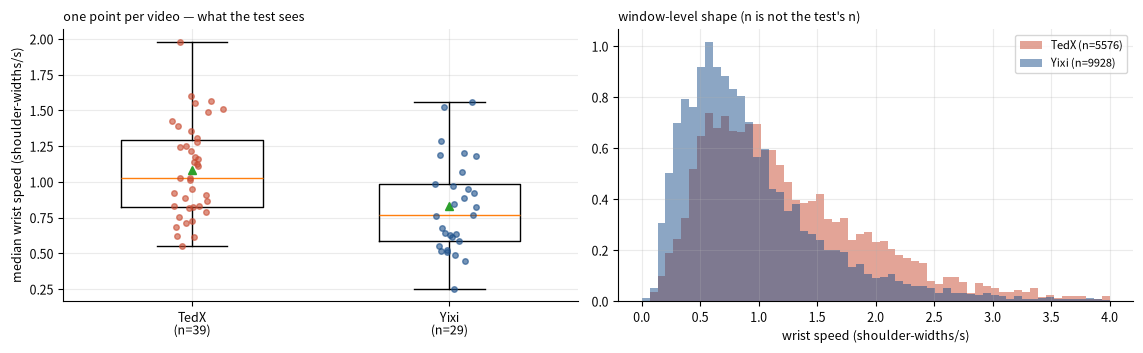

In [5]:
if not READY:
    print("skipped — see guard")
else:
    rows = []
    for col, label in [("wrist_speed_mean", "wrist speed (shoulder-widths/s)"),
                       ("wrist_speed_p90", "wrist speed, 90th pct"),
                       ("mean_wrist_velocity", "[not used] pixels/s")]:
        row, a, b = video_level_test(col, label)
        if row:
            rows.append(row)
    display(pd.DataFrame(rows).set_index("measure"))
    print(f"effect sign: positive = {A} higher")

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
    # per-video medians — what the test actually sees
    _, a, b = video_level_test("wrist_speed_mean", "")
    # set_xticks rather than boxplot(labels=...): that kwarg was renamed
    # tick_labels in matplotlib 3.9, and this form works on both.
    axes[0].boxplot([a, b], widths=0.55, showmeans=True)
    axes[0].set_xticks([1, 2], [f"{A}\n(n={len(a)})", f"{B}\n(n={len(b)})"])
    for i, (s, name) in enumerate([(a, A), (b, B)], start=1):
        axes[0].scatter(np.random.normal(i, 0.045, len(s)), s, s=16, alpha=0.6,
                        color=COLOUR[name], zorder=3)
    axes[0].set_ylabel("median wrist speed (shoulder-widths/s)")
    axes[0].set_title("one point per video — what the test sees", loc="left", fontsize=9)

    # window-level shape
    for name in (A, B):
        vals = dfs[name].wrist_speed_mean.dropna()
        axes[1].hist(vals, bins=np.linspace(0, 4, 60), density=True, alpha=0.5,
                     color=COLOUR[name], label=f"{name} (n={len(vals)})")
    axes[1].set_xlabel("wrist speed (shoulder-widths/s)")
    axes[1].set_title("window-level shape (n is not the test's n)", loc="left", fontsize=9)
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

## 5. Pitch level  — spec §4

**Comparable: level. Not comparable: variation.**

`pitch_st` is semitones from each speaker's own median, so a deep voice and a
high voice both centre on zero and what remains is how far a speaker departs
from their own baseline. That survives the language difference.

`pitch_var_st` does not, and is deliberately absent from the test table.
Mandarin carries lexical tone on f0, so within-window variation there is tone
plus intonation, while in English it is intonation alone. The two numbers have
the same units and measure different things — the most dangerous kind of
incomparability, because nothing about the data announces it.

The speaker baselines are shown because they are the reason §4 insists on
speaker-relative measures in the first place.

,TedX median,Yixi median,n TedX,n Yixi,p,effect (rank-biserial),size
measure,,,,,,,
pitch level (semitones from own median),0.000,0.000,39,29,0.0735,-0.231,small
intensity (dB),62.546,59.887,39,29,0.107,0.231,small


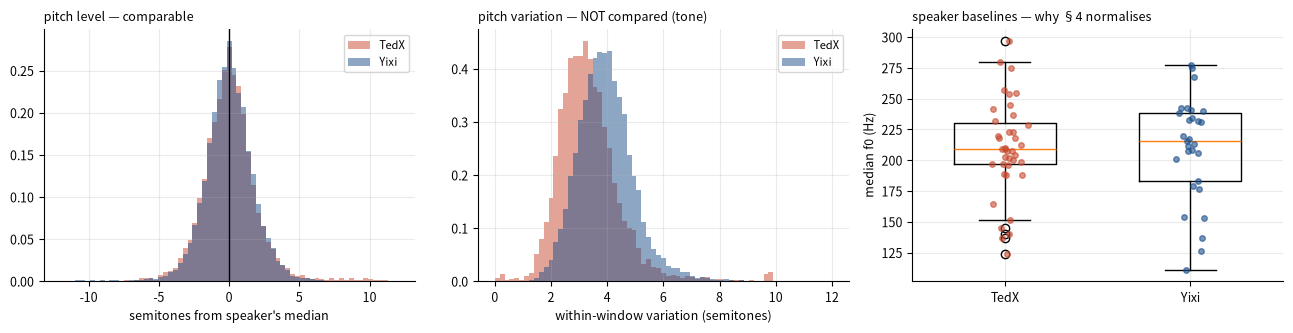

Chinese within-window pitch variation is tone + intonation; English is intonation alone. The middle panel is plotted, not tested.
   TedX   median pitch_var_st = 3.22 st
   Yixi   median pitch_var_st = 3.89 st


In [6]:
if not READY:
    print("skipped — see guard")
else:
    rows = []
    for col, label in [("pitch_st", "pitch level (semitones from own median)"),
                       ("mean_intensity_db", "intensity (dB)")]:
        row, _, _ = video_level_test(col, label)
        if row:
            rows.append(row)
    display(pd.DataFrame(rows).set_index("measure"))

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
    for name in (A, B):
        axes[0].hist(dfs[name].pitch_st.dropna(), bins=np.linspace(-12, 12, 70),
                     density=True, alpha=0.5, color=COLOUR[name], label=name)
    axes[0].axvline(0, color="k", lw=1)
    axes[0].set_xlabel("semitones from speaker's median")
    axes[0].set_title("pitch level — comparable", loc="left", fontsize=9)
    axes[0].legend(fontsize=8)

    for name in (A, B):
        axes[1].hist(dfs[name].pitch_var_st.dropna(), bins=np.linspace(0, 12, 70),
                     density=True, alpha=0.5, color=COLOUR[name], label=name)
    axes[1].set_xlabel("within-window variation (semitones)")
    axes[1].set_title("pitch variation — NOT compared (tone)", loc="left", fontsize=9)
    axes[1].legend(fontsize=8)

    base = {name: dfs[name].groupby("job_id").mean_f0.median().dropna() for name in (A, B)}
    axes[2].boxplot([base[A], base[B]], widths=0.55)
    axes[2].set_xticks([1, 2], [A, B])
    for i, name in enumerate((A, B), start=1):
        axes[2].scatter(np.random.normal(i, 0.045, len(base[name])), base[name],
                        s=16, alpha=0.6, color=COLOUR[name], zorder=3)
    axes[2].set_ylabel("median f0 (Hz)")
    axes[2].set_title("speaker baselines — why §4 normalises", loc="left", fontsize=9)
    plt.tight_layout(); plt.show()

    print("Chinese within-window pitch variation is tone + intonation; English is "
          "intonation alone. The middle panel is plotted, not tested.")
    for name in (A, B):
        print(f"   {name:<6} median pitch_var_st = {dfs[name].pitch_var_st.median():.2f} st")

### The two assumption corners, compared  — §4's comparison step

§4 asks for the working assumption to be preserved — low + stable =
authoritative/assertive, high + variable = emotional/engaging — and its scope
line covers the EN–ZH comparison, so the corners belong here as well as in the
single-corpus notebooks.

**What is actually comparable here is the association, not the amount.** Both
axes are tertiles computed *within each speaker*, so every speaker contributes
exactly a third of their windows to each level and each variation band by
construction. The marginals are therefore identical in both corpora by
definition, and only the *joint* distribution is free to differ. A corpus where
low pitch and stable delivery coincide more often than chance is one where the
two travel together — which is what the assumption claims.

Cramér's V measures that dependence. If it is near zero in both corpora, level
and variation are independent and the two "corners" are not coherent styles but
arithmetic — a caution worth having before either is used as evidence.

,windows,low+stable %,high+variable %,if independent %,Cramer's V,dependence
corpus,,,,,,
TedX,5946,15.3,14.0,11.1,0.144,small
Yixi,10751,15.5,13.2,11.1,0.144,small


Both corners would sit at 11.1% if pitch level and variation were independent within a speaker.


,TedX mean share,Yixi mean share,n TedX,n Yixi,p,effect
corner,,,,,,
low+stable,15.4%,15.4%,39,29,0.931,0.013
high+variable,14.2%,13.2%,39,29,0.254,0.164


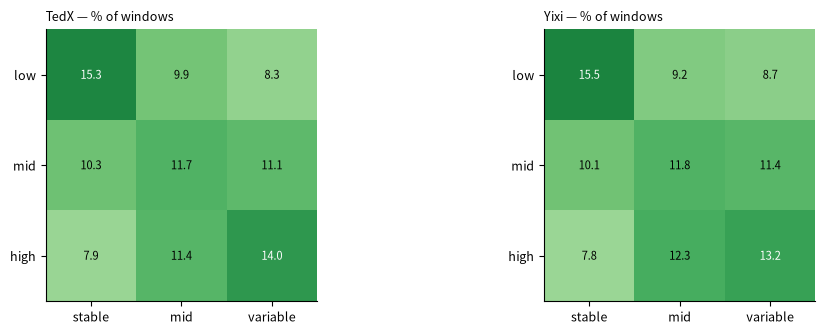

Reminder: for Yixi the variation axis carries lexical tone as well as intonation. Within-speaker tertiles keep the ranking meaningful, but 'variable' does not mean the same thing in the two corpora.


In [7]:
if not READY:
    print("skipped — see guard")
else:
    from scipy.stats import chi2_contingency

    LEVELS = ["low", "mid", "high"]
    VARS = ["stable", "mid", "variable"]

    rows = []
    for name in (A, B):
        d = dfs[name].dropna(subset=["pitch_level", "pitch_variation"])
        tab = pd.crosstab(d.pitch_level, d.pitch_variation).reindex(
            index=LEVELS, columns=VARS).fillna(0)
        chi2, p_c, dof, _ = chi2_contingency(tab)
        n = tab.values.sum()
        v = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
        share = (tab / n * 100)
        rows.append({
            "corpus": name,
            "windows": int(n),
            "low+stable %": round(share.loc["low", "stable"], 1),
            "high+variable %": round(share.loc["high", "variable"], 1),
            "if independent %": round(100 / 9, 1),
            "Cramer's V": round(v, 3),
            "dependence": ("negligible" if v < 0.1 else "small" if v < 0.3
                           else "moderate" if v < 0.5 else "large"),
        })
    display(pd.DataFrame(rows).set_index("corpus"))
    print("Both corners would sit at 11.1% if pitch level and variation were "
          "independent within a speaker.")

    # Per-video corner shares, so the comparison has an honest n.
    corner = {}
    for label, lvl, var in [("low+stable", "low", "stable"),
                            ("high+variable", "high", "variable")]:
        per = {}
        for name in (A, B):
            d = dfs[name].dropna(subset=["pitch_level", "pitch_variation"])
            per[name] = (d.groupby("job_id")
                         .apply(lambda g: ((g.pitch_level == lvl) &
                                           (g.pitch_variation == var)).mean())
                         .dropna())
        u, p_v = mannwhitneyu(per[A], per[B], alternative="two-sided")
        rb = -(1 - (2 * u) / (len(per[A]) * len(per[B])))
        corner[label] = (per, p_v, rb)

    display(pd.DataFrame([
        {"corner": label,
         f"{A} mean share": f"{per[A].mean():.1%}",
         f"{B} mean share": f"{per[B].mean():.1%}",
         f"n {A}": len(per[A]), f"n {B}": len(per[B]),
         "p": f"{p_v:.3g}", "effect": round(rb, 3)}
        for label, (per, p_v, rb) in corner.items()
    ]).set_index("corner"))

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    for ax, name in zip(axes, (A, B)):
        d = dfs[name].dropna(subset=["pitch_level", "pitch_variation"])
        tab = (pd.crosstab(d.pitch_level, d.pitch_variation, normalize=True) * 100)
        tab = tab.reindex(index=LEVELS, columns=VARS).fillna(0)
        im = ax.imshow(tab.values, cmap="Greens", vmin=0, vmax=20)
        ax.set_xticks(range(3), VARS); ax.set_yticks(range(3), LEVELS)
        ax.set_title(f"{name} — % of windows", loc="left", fontsize=9); ax.grid(False)
        for i in range(3):
            for j in range(3):
                val = tab.values[i, j]
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8,
                        color="white" if val > 13 else "black")
    plt.tight_layout(); plt.show()

    print("Reminder: for YiXi the variation axis carries lexical tone as well as "
          "intonation. Within-speaker tertiles keep the ranking meaningful, but "
          "'variable' does not mean the same thing in the two corpora.")

## 6. Shots and angles  — spec §3

**Comparable**, with a caveat about what a difference means. The classifier is
the same for both corpora, so the categories are commensurable. But editing is
a production decision: YiXi is a studio format with a fixed stage, TED is many
venues and crews. A difference here is evidence about the broadcasters at
least as much as about the speakers.

§3 asks for a chi-square. It is computed below over windows, **and** checked at
the video level, because the window-level test suffers the same
pseudo-replication as everything else: with ~20,000 windows, chi-square will
return p ≈ 0 for a difference of no consequence. Cramér's V is the number to
read, and the standardised residuals say *which* cells drive it.

§3 also asks for duration normalisation before comparing corpora, which the
shots-per-minute test at the end supplies. Both it and the percentages are
computed from the same per-window tally: shares are of **windows**, so they
describe how screen time is distributed rather than how many editorial
decisions were made. A long shot held across six windows counts six times, and
that is the intended reading here.


=== dominant_shot_type
    chi2=2145.1  dof=6  p=0  Cramer's V=0.370  (moderate)


dominant_shot_type,close_up %,extreme_close_up %,long %,medium %,medium_close %,medium_long %,very_long %,close_up resid,extreme_close_up resid,long resid,medium resid,medium_close resid,medium_long resid,very_long resid
corpus,,,,,,,,,,,,,,
TedX,49.5,1.0,20.2,2.2,19.7,2.3,5.1,22.4,7.7,0.7,8.0,-3.3,-0.7,-27.1
Yixi,23.0,0.0,19.6,0.5,22.9,2.5,31.6,-16.8,-5.8,-0.5,-6.0,2.5,0.5,20.4



=== horizontal_angle
    chi2=884.5  dof=2  p=8.64e-193  Cramer's V=0.237  (small)


horizontal_angle,frontal %,oblique %,transitional %,frontal resid,oblique resid,transitional resid
corpus,,,,,,
TedX,42.7,29.1,28.1,-15.4,13.3,12.3
Yixi,67.1,16.4,16.5,11.5,-10.0,-9.3



=== vertical_angle
    chi2=11.8  dof=2  p=0.00277  Cramer's V=0.027  (negligible)


vertical_angle,eye_level %,high %,low %,eye_level resid,high resid,low resid
corpus,,,,,,
TedX,13.6,0.1,86.3,-2.4,0.8,1.0
Yixi,15.5,0.1,84.4,1.8,-0.6,-0.7



Standardised residual beyond +/-2 marks a cell contributing disproportionately. Positive = more than expected under independence.


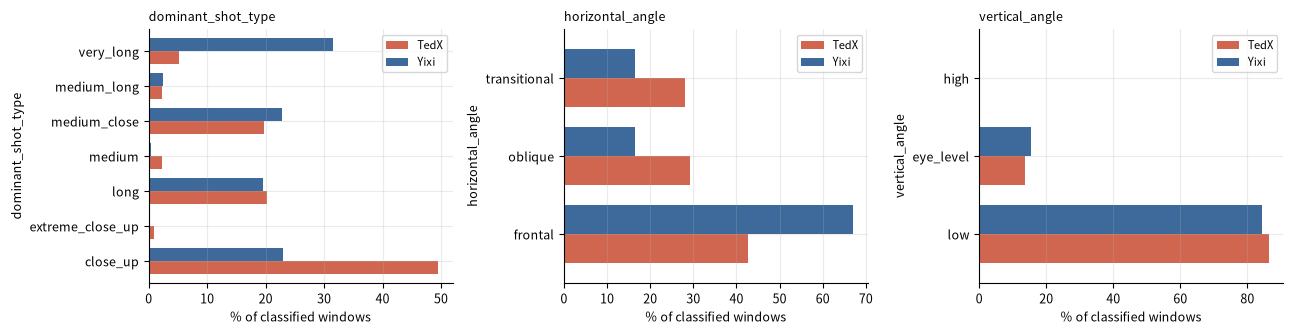

In [8]:
if not READY:
    print("skipped — see guard")
else:
    from scipy.stats import chi2_contingency

    for col in ["dominant_shot_type", "horizontal_angle", "vertical_angle"]:
        tab = pd.crosstab(both.corpus, both[col])
        if tab.shape[1] < 2:
            continue
        chi2, p, dof, exp = chi2_contingency(tab)
        n = tab.values.sum()
        v = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
        print(f"\n=== {col}")
        print(f"    chi2={chi2:.1f}  dof={dof}  p={p:.3g}  Cramer's V={v:.3f}  "
              f"({'negligible' if v<0.1 else 'small' if v<0.3 else 'moderate' if v<0.5 else 'large'})")
        pct = (tab.T / tab.sum(axis=1)).T * 100
        resid = (tab - exp) / np.sqrt(exp)
        out = pd.concat([pct.round(1).add_suffix(" %"),
                         resid.round(1).add_suffix(" resid")], axis=1)
        display(out)

    print("\nStandardised residual beyond +/-2 marks a cell contributing "
          "disproportionately. Positive = more than expected under independence.")

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
    for ax, col in zip(axes, ["dominant_shot_type", "horizontal_angle", "vertical_angle"]):
        tab = pd.DataFrame({name: dfs[name][col].value_counts(normalize=True) * 100
                            for name in (A, B)}).fillna(0)
        tab.plot.barh(ax=ax, color=[COLOUR[A], COLOUR[B]], alpha=0.85, width=0.75)
        ax.set_title(col, fontsize=9, loc="left"); ax.set_xlabel("% of classified windows")
        ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

### The same comparison at the video level

Each video's own share of close-ups (etc.), then compared across corpora. This
is the version whose n is real. If a category is significant here as well as in
the chi-square, the difference is not an artefact of window counting.

In [9]:
if not READY:
    print("skipped — see guard")
else:
    rows = []
    for col in ["dominant_shot_type", "horizontal_angle", "vertical_angle"]:
        cats = both[col].dropna().unique()
        for cat in sorted(cats):
            share = {}
            for name in (A, B):
                d = dfs[name]
                per_video = (d.dropna(subset=[col]).groupby("job_id")[col]
                             .apply(lambda s: (s == cat).mean()))
                share[name] = per_video.dropna()
            if min(len(share[A]), len(share[B])) < 3:
                continue
            u, p = mannwhitneyu(share[A], share[B], alternative="two-sided")
            rb = -(1 - (2 * u) / (len(share[A]) * len(share[B])))
            rows.append({
                "variable": col, "category": cat,
                f"{A} mean share": f"{share[A].mean():.1%}",
                f"{B} mean share": f"{share[B].mean():.1%}",
                "p": f"{p:.3g}", "effect": round(rb, 3),
            })
    tab = pd.DataFrame(rows)
    display(tab.set_index(["variable", "category"]))

    # ── Shots per minute — §3's duration normalisation ──────────────────
    # Counted from the per-window cut counts, the same source as the
    # percentages above, so both halves of §3 rest on one tally. A video with
    # n cuts contains n+1 shots.
    #
    # This normalisation is not decorative here: the median YiXi talk runs
    # 31 minutes against Ted's 13, so any raw count of shots would favour
    # YiXi 2.4-fold before a single editorial difference is considered.
    rate = {}
    for name in (A, B):
        cuts = dfs[name].groupby("job_id").cut_count.sum()
        mins = videos[name].set_index("job_id").duration_s / 60
        rate[name] = ((cuts + 1) / mins).dropna()
    u, p_rate = mannwhitneyu(rate[A], rate[B], alternative="two-sided")
    rb_rate = -(1 - (2 * u) / (len(rate[A]) * len(rate[B])))

    display(pd.DataFrame([{
        "measure": "shots per minute",
        f"{A} median": round(rate[A].median(), 2),
        f"{B} median": round(rate[B].median(), 2),
        f"{A} range": f"{rate[A].min():.1f}-{rate[A].max():.1f}",
        f"{B} range": f"{rate[B].min():.1f}-{rate[B].max():.1f}",
        f"n {A}": len(rate[A]), f"n {B}": len(rate[B]),
        "p": f"{p_rate:.3g}", "effect": round(rb_rate, 3),
    }]).set_index("measure"))
    print("mean shot length follows directly: 60 / shots-per-minute = "
          f"{60/rate[A].median():.1f}s ({A}) vs {60/rate[B].median():.1f}s ({B})")

TedX mean share Yixi mean share         p  effect
variable           category                                                          
dominant_shot_type close_up                   48.9%           21.9%  1.09e-06   0.696
                   extreme_close_up            0.8%            0.0%     0.447   0.045
                   long                       20.9%           19.7%     0.527   0.091
                   medium                      2.1%            0.5%    0.0238   0.296
                   medium_close               19.7%           23.1%     0.303  -0.148
                   medium_long                 2.5%            2.5%     0.937  -0.011
                   very_long                   5.1%           32.3%   1.9e-09  -0.855
horizontal_angle   frontal                    43.6%           67.5%  5.85e-11  -0.935
                   oblique                    28.7%           16.0%  1.59e-06   0.685
                   transitional               27.8%           16.5%  2.97e-08   0.791
vertical_angle     eye_level                  15.3%           16.2%     0.585   0.079
                   high                        0.2%            0.1%     0.801  -0.019
                   low                        84.6%           83.7%     0.585  -0.079

,TedX median,Yixi median,TedX range,Yixi range,n TedX,n Yixi,p,effect
measure,,,,,,,,
shots per minute,5.72,5.61,3.7-9.7,3.0-12.5,39,29,0.298,0.149


mean shot length follows directly: 60 / shots-per-minute = 10.5s (TedX) vs 10.7s (Yixi)


## 7. Keyness over mapped concepts  — spec §2 and §7.3

Keyness normally compares one corpus' word frequencies against another's. That
is impossible here: *woman* and 女性 are different strings, and no amount of
statistics bridges them. §7.3 calls for a curated concept mapping, and
`flags/concepts_en_zh.yaml` is it — the document's own 28 concepts (§7.3.1),
each with an English and a Chinese word list.

So the unit of comparison is the **concept**, not the word. For each concept,
its member words are counted in each corpus and expressed per 1,000 tokens of
that corpus.

Every form in that file was checked against these corpora before inclusion, for
two reasons that would each silently corrupt the result. English is matched by
**surface form**, so inflections are listed individually — leaving them implicit
undercounts English verbs by ~30% and biases every comparison against it.
Chinese must be **single pkuseg tokens**, since a multi-word entry can never
match. Variants are kept distinct rather than merged, per §7.3: 女权主义 against
女性主义 is a difference of register, and averaging them away would discard the
finding.

**Log-likelihood (G²)** is the standard corpus-linguistics keyness statistic;
**Log Ratio** is the effect size — +1 means twice as frequent, +2 four times.
Read the effect size. With corpora this large, G² passes any threshold for
differences too small to matter.

Three caveats, all of which limit what this can support:

* **The word lists are the spreadsheet's seed examples, not curated lists.** A
  concept's rate is the rate of *the words listed*, so a low figure may mean
  the concept is rare or merely that its list is short. Comparing across
  corpora partially cancels this only if the two lists are equally complete,
  which is not guaranteed.
* **Tokens are per-language.** Rates are per 1,000 segmented words in each
  corpus' own tokenisation. That is the usual practice in cross-linguistic
  corpus work, and it is still an approximation.
* **A list must match the tokeniser to mean anything.** Word lists are matched
  against single segmented tokens, so a multi-word entry never matches. The
  Chinese passives are written 被压迫, 被忽视 and so on, which pkuseg splits
  into 被 + 压迫 — all six entries score zero, which would otherwise read as
  "English uses vastly more passives" when it really means the list cannot
  fire. The table reports how many of each list's words were found, and any
  concept matching nothing in a language is excluded and shown separately.
* **`proper_nouns` is excluded** — it has no word list in either language, only
  a part-of-speech, and the stored tag is unreliable until the verbal backfill
  has run everywhere.

In [10]:
import yaml

CONCEPTS = Path.cwd().parent / "flags" / "concepts_en_zh.yaml"
if not CONCEPTS.exists():
    CONCEPTS = Path.cwd() / "flags" / "concepts_en_zh.yaml"


def log_likelihood(a, b, c, d):
    """G^2 for freq a in corpus of c tokens vs freq b in corpus of d tokens."""
    e1 = c * (a + b) / (c + d)
    e2 = d * (a + b) / (c + d)
    ll = 0.0
    if a: ll += a * np.log(a / e1)
    if b: ll += b * np.log(b / e2)
    return 2 * ll


def log_ratio(a, c, b, d):
    """Hardie's Log Ratio, with a 0.5 continuity correction for zero counts."""
    return np.log2(((a + 0.5) / c) / ((b + 0.5) / d))


if READY:
    spec_file = yaml.safe_load(CONCEPTS.read_text())
    lexicons = spec_file["concepts"]
    print(f"{spec_file['id']} v{spec_file['version']} — {len(lexicons)} concepts "
          f"from {spec_file.get('source', 'unknown source')}")

    # Merged across parts of speech: the concept is about the word, and the
    # stored tag is per-video and unreliable pre-backfill.
    wl = {name: data[name].wordlist(by_pos=False) for name in (A, B)}
    counts = {name: dict(zip(wl[name].word, wl[name]["count"])) for name in (A, B)}
    totals = {name: float(wl[name].attrs["corpus_tokens"]) for name in (A, B)}
    lang_of = {A: "en", B: "zh"}

    rows, skipped = [], []
    for concept, spec in lexicons.items():
        words = {name: [w.lower() for w in (spec.get(lang_of[name]) or [])] for name in (A, B)}
        if not words[A] or not words[B]:
            skipped.append(concept)
            continue
        freq = {name: sum(counts[name].get(w, 0) for w in words[name]) for name in (A, B)}
        # How many of the listed words occur at all. A concept whose list
        # matches nothing is not a rare concept, it is a broken list, and a
        # rate of 0 would read as an enormous cross-corpus difference. The
        # usual cause is a multi-token entry: the Chinese passives are written
        # 被压迫, which pkuseg segments as 被 + 压迫, so the bigram can never
        # match a word list built from single tokens.
        matched = {name: sum(1 for w in words[name] if counts[name].get(w, 0))
                   for name in (A, B)}
        g2 = log_likelihood(freq[A], freq[B], totals[A], totals[B])
        lr = log_ratio(freq[A], totals[A], freq[B], totals[B])
        rows.append({
            "concept": concept,
            f"{A} n": freq[A], f"{B} n": freq[B],
            f"{A} /1k": round(freq[A] / totals[A] * 1000, 3),
            f"{B} /1k": round(freq[B] / totals[B] * 1000, 3),
            "G2": round(g2, 1),
            "log ratio": round(lr, 2),
            "favours": A if lr > 0 else B,
            f"{A} matched": f"{matched[A]}/{len(words[A])}",
            f"{B} matched": f"{matched[B]}/{len(words[B])}",
            "usable": bool(matched[A] and matched[B]),
        })

    key_all = pd.DataFrame(rows).sort_values("log ratio", ascending=False)
    key = key_all[key_all.usable].drop(columns="usable")
    display(key.set_index("concept"))
    print(f"tokens — {A}: {totals[A]:,.0f}   {B}: {totals[B]:,.0f}")
    print("G2 thresholds (1 df): 3.84 p<.05 | 6.63 p<.01 | 10.83 p<.001 | 15.13 p<.0001")
    if skipped:
        print(f"\nno word list in one or both languages: {', '.join(skipped)}")

    broken = key_all[~key_all.usable]
    if not broken.empty:
        print("\nEXCLUDED — a word list that matched nothing, so its rate of 0 is a "
              "property of the list, not of the corpus:")
        display(broken.set_index("concept")[
            [f"{A} n", f"{B} n", f"{A} matched", f"{B} matched", "log ratio"]])
        print("A multi-token phrase cannot match a word list built from single "
              "tokens. The same limitation applies to these lexicons in the "
              "flagging system, where such a criterion simply never fires.")

multiarth-concepts v1 — 28 concepts from MultiArth_Search_Bar_QUANTITATIVE.docx §7.3.1


,TedX n,Yixi n,TedX /1k,Yixi /1k,G2,log ratio,favours,TedX matched,Yixi matched
concept,,,,,,,,,
power,66,42,0.991,0.289,40.1,1.77,TedX,3/3,3/3
girl,184,144,2.763,0.992,84.6,1.48,TedX,2/2,4/4
man,211,170,3.168,1.171,92.7,1.43,TedX,2/2,2/2
gender,131,120,1.967,0.827,46.2,1.25,TedX,3/3,2/2
strength_empowerment,50,46,0.751,0.317,17.5,1.24,TedX,8/8,5/5
body,75,72,1.126,0.496,24.2,1.18,TedX,3/3,4/4
woman,537,589,8.063,4.058,128.5,0.99,TedX,2/2,4/4
discrimination,42,56,0.631,0.386,5.6,0.71,TedX,7/7,3/3
equality,58,90,0.871,0.620,4.0,0.49,TedX,6/6,3/3


tokens — TedX: 66,604   Yixi: 145,142
G2 thresholds (1 df): 3.84 p<.05 | 6.63 p<.01 | 10.83 p<.001 | 15.13 p<.0001

no word list in one or both languages: intersectionality, queer

EXCLUDED — a word list that matched nothing, so its rate of 0 is a property of the list, not of the corpus:


,TedX n,Yixi n,TedX matched,Yixi matched,log ratio
concept,,,,,
sexuality,134,0,4/4,0/2,9.2


A multi-token phrase cannot match a word list built from single tokens. The same limitation applies to these lexicons in the flagging system, where such a criterion simply never fires.


### Reading the keyness

Bars are Log Ratio: right of zero means more frequent in Ted, left means more
frequent in YiXi. Bar length is the size of the difference, and the label gives
G² so a large effect resting on few tokens is visible as such.

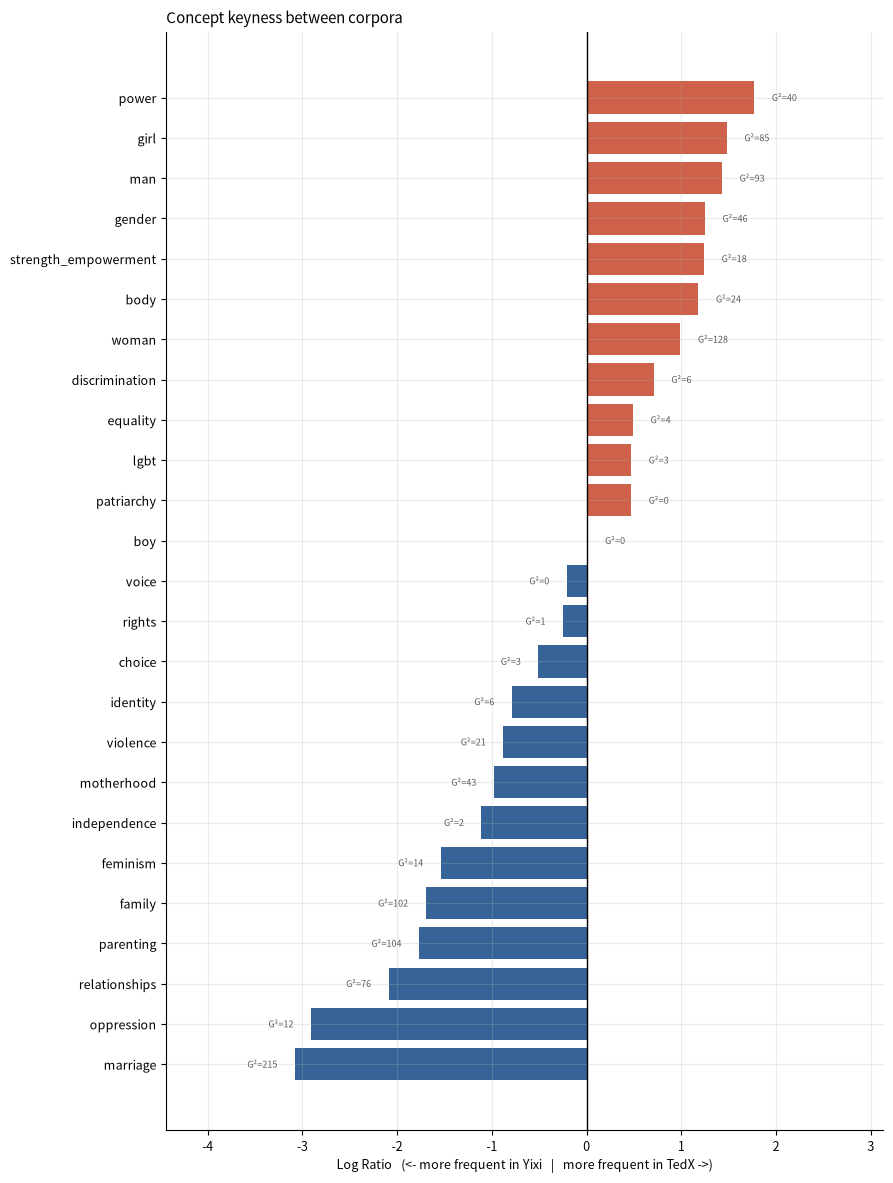

A concept with a large |log ratio| but small G2 rests on few tokens — check the n columns before quoting it.


In [11]:
if READY and not key.empty:
    k = key.sort_values("log ratio")
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(k) + 1.4))
    colours = [COLOUR[A] if v > 0 else COLOUR[B] for v in k["log ratio"]]
    ax.barh(k.concept, k["log ratio"], color=colours, alpha=0.88)
    ax.axvline(0, color="k", lw=1)
    ax.set_xlabel(f"Log Ratio   (<- more frequent in {B}   |   more frequent in {A} ->)")
    ax.set_title("Concept keyness between corpora", loc="left")
    span = max(abs(k["log ratio"].min()), abs(k["log ratio"].max()))
    for y, (_, r) in enumerate(k.iterrows()):
        off = 0.06 * span * (1 if r["log ratio"] > 0 else -1)
        ax.text(r["log ratio"] + off, y, f"G²={r.G2:,.0f}", va="center",
                ha="left" if r["log ratio"] > 0 else "right", fontsize=6.5, color="0.35")
    ax.margins(x=0.28)
    plt.tight_layout(); plt.show()

    print("A concept with a large |log ratio| but small G2 rests on few tokens — "
          "check the n columns before quoting it.")

## 8. What is deliberately not compared

Not oversights. Each of these has a stored column that would produce a number
and a plot, and each would be wrong.

| measure | why not | what it would take |
|---|---|---|
| `pitch_var_st` | Mandarin f0 carries lexical tone; English f0 does not. Same units, different constructs | syllable-aligned f0 and a tone model, to separate tone from intonation. The dense contours from `scripts/backfill_dense_prosody.py` are the prerequisite and are stored |
| `speech_rate_syl_per_s` | Chinese is counted from Han characters; English is estimated as word count × 1.5. One instrument each | an English syllable counter — a pronunciation dictionary such as CMUdict, with a fallback for out-of-vocabulary words |
| `word_count` | a pkuseg word and an English whitespace word are different units | nothing makes these directly comparable; syllables or characters per second is the measure that transfers |
| `mean_f0` | tracks voice type and speaker sex far more strongly than style | already solved — use `pitch_st`, which is what section 5 does |
| `mean_wrist_velocity`, `max_wrist_displacement` | pixels: confounded with resolution and shot scale | already solved — use `wrist_speed_mean`, which section 4 does |
| n-grams, collocations | surface forms, no cross-language bridge | a concept-level equivalent of section 7, over multi-word units |

The general rule these follow: a measure crosses the language boundary only if
it is **a ratio whose units cancel** (body-normalised gesture), **relative to
the speaker's own baseline** (pitch in semitones), **assigned by one
language-blind classifier** (shot type), or **mapped through an explicit
bridge** (section 7's concepts). Anything else is comparing instruments.

## 9. Reading these results

* **n is videos, not windows.** Every p-value here rests on 39 and 27 talks.
  The window-level histograms show distribution shape and nothing more; the
  earlier version of this notebook tested at window level and its p-values
  should not be quoted.
* **Corpus is confounded with language, genre, venue, production team and
  topic.** Nothing here isolates "English speakers gesture more". At best it
  says the two *corpora* differ, and the interesting work is arguing which
  confound is responsible.
* **Read `pose_coverage` before any gesture claim.** It differs by corpus, and
  gesture measures exist only where a pose was tracked, so the two corpora's
  gesture statistics are computed over differently-selected windows.
* **Framing differences may be about the broadcaster.** YiXi is one studio
  format; TED is many venues. Section 6's differences are real and their cause
  is likely production, not speaker.
* **Keyness is provisional until the word lists are curated.** Section 7's
  concept rates are rates of the listed words, and those lists are the
  spreadsheet's examples.
* **Effect sizes, not p-values.** Cramér's V, Log Ratio and rank-biserial are
  the numbers to quote. At these corpus sizes significance is cheap.